### **AI-Powered Medical Image Disease Detection**

Business Problem

Hospitals want an AI system that detects pneumonia from X-ray images.


In [ ]:
import kagglehub

path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Path to dataset files: /kaggle/input/chest-xray-pneumonia


In [ ]:
import os
for root, dirs, files in os.walk(path):
    print(root)
    break

/kaggle/input/chest-xray-pneumonia


In [ ]:
import os
for root, dirs, files in os.walk(path):
    print(root)

/kaggle/input/chest-xray-pneumonia
/kaggle/input/chest-xray-pneumonia/chest_xray
/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray
/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/val
/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA
/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/val/NORMAL
/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/test
/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/test/PNEUMONIA
/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/test/NORMAL
/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/train
/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/train/PNEUMONIA
/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/train/NORMAL
/kaggle/input/chest-xray-pneumonia/chest_xray/__MACOSX
/kaggle/input/chest-xray-pneumonia/chest_xray/__MACOSX/chest_xray
/kaggle/input/chest-xray-pneumonia/chest_xray/__MACOSX/chest_xray/val
/kaggle/input/chest-xray-pneumonia/chest_xray/__MACOSX/chest_x

In [ ]:
train_dir = os.path.join(path, "chest_xray", "train")
test_dir = os.path.join(path, "chest_xray", "test")
val_dir = os.path.join(path, "chest_xray", "val")

### **Tasks**


**Phase 1**

Preprocess images

Resize

Normalize

Augment

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
#resize, normalize, augment
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [ ]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

val_generator = test_datagen.flow_from_directory(
    val_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [ ]:
print("Training Images :", train_generator.samples)
print("Validation Images :", val_generator.samples)
print("Testing Images :", test_generator.samples)
print("Class Labels :", train_generator.class_indices)

Training Images : 5216
Validation Images : 16
Testing Images : 624
Class Labels : {'NORMAL': 0, 'PNEUMONIA': 1}


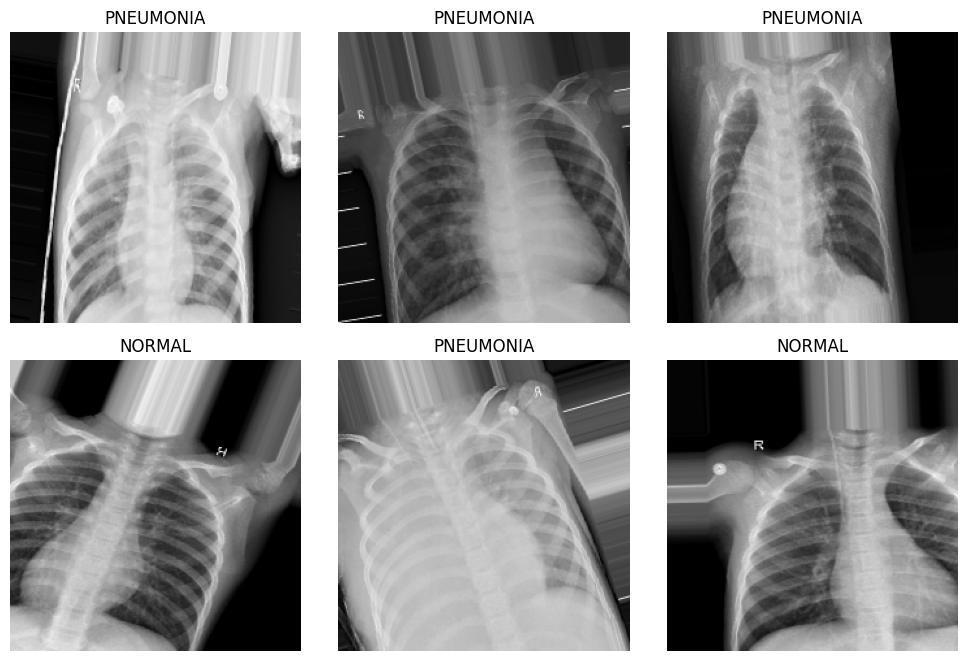

In [ ]:
import matplotlib.pyplot as plt

images, labels = next(train_generator)
plt.figure(figsize=(10,10))
for i in range(6):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.title("PNEUMONIA" if labels[i]==1 else "NORMAL")
    plt.axis("off")

plt.tight_layout()
plt.show()

**Phase 2**

Build CNN

Layers:

Conv2D

MaxPooling

Dropout

Dense


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

In [ ]:
model = Sequential()

model.add(Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Conv2D(128,(3,3),activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(128,activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 171s 998ms/step - accuracy: 0.8050 - loss: 0.4244 - val_accuracy: 0.8125 - val_loss: 0.4438
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 110s 675ms/step - accuracy: 0.8656 - loss: 0.3030 - val_accuracy: 0.6875 - val_loss: 0.5982
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 112s 689ms/step - accuracy: 0.8790 - loss: 0.2807 - val_accuracy: 0.6250 - val_loss: 0.8780
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 109s 668ms/step - accuracy: 0.8880 - loss: 0.2679 - val_accuracy: 0.6250 - val_loss: 0.7703
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 108s 662ms/step - accuracy: 0.8978 - loss: 0.2425 - val_accuracy: 0.8125 - val_loss: 0.4080
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 108s 664ms/step - accuracy: 0.9009 - loss: 0.2367 - val_accuracy: 0.8125 - val_loss: 0.6655
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 108s 664ms/step - accuracy: 0.8969 - loss: 0.2462 - val_accuracy: 0.6250 - val_loss: 0.9404
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 105s 643ms/step - accuracy: 0.9080 -

In [14]:
loss, accuracy = model.evaluate(test_generator)

print("Test Accuracy:", accuracy)
print("Test Loss:", loss)

20/20 ━━━━━━━━━━━━━━━━━━━━ 15s 658ms/step - accuracy: 0.8237 - loss: 0.4492
Test Accuracy: 0.8237179517745972
Test Loss: 0.44920873641967773


In [15]:
model.save("pneumonia_cnn_model.h5")

In [17]:
from google.colab import files
files.download("pneumonia_cnn_model.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Phase 3**

Experiment

Compare:

CNN,
Transfer Learning


In [18]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

y_true = test_generator.classes
y_pred_prob = model.predict(test_generator)

y_pred = (y_pred_prob > 0.5).astype(int)

cnn_accuracy = accuracy_score(y_true, y_pred)
cnn_precision = precision_score(y_true, y_pred)
cnn_recall = recall_score(y_true, y_pred)

print("CNN Accuracy :", cnn_accuracy)
print("CNN Precision:", cnn_precision)
print("CNN Recall   :", cnn_recall)

20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 244ms/step
CNN Accuracy : 0.5833333333333334
CNN Precision: 0.6359832635983264
CNN Recall   : 0.7794871794871795


In [19]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense

In [20]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

transfer_model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')
])

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [21]:
transfer_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [22]:
history_transfer = transfer_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 135s 711ms/step - accuracy: 0.9057 - loss: 0.2111 - val_accuracy: 0.8125 - val_loss: 0.4102
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 102s 627ms/step - accuracy: 0.9369 - loss: 0.1494 - val_accuracy: 0.8750 - val_loss: 0.3284
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 103s 629ms/step - accuracy: 0.9482 - loss: 0.1293 - val_accuracy: 0.8750 - val_loss: 0.3874
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 104s 637ms/step - accuracy: 0.9454 - loss: 0.1338 - val_accuracy: 0.8750 - val_loss: 0.3202
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 118s 724ms/step - accuracy: 0.9477 - loss: 0.1272 - val_accuracy: 0.8750 - val_loss: 0.5141
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 108s 661ms/step - accuracy: 0.9542 - loss: 0.1163 - val_accuracy: 0.8125 - val_loss: 0.4256
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 106s 648ms/step - accuracy: 0.9507 - loss: 0.1205 - val_accuracy: 0.8125 - val_loss: 0.4171
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 107s 657ms/step - accuracy: 0.9511 -

In [23]:
loss, accuracy = transfer_model.evaluate(test_generator)
print("Transfer Learning Accuracy:", accuracy)

20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 232ms/step - accuracy: 0.8686 - loss: 0.3584
Transfer Learning Accuracy: 0.8685897588729858


In [24]:
y_pred_prob_tl = transfer_model.predict(test_generator)
y_pred_tl = (y_pred_prob_tl > 0.5).astype(int)

tl_accuracy = accuracy_score(y_true, y_pred_tl)
tl_precision = precision_score(y_true, y_pred_tl)
tl_recall = recall_score(y_true, y_pred_tl)

print("Transfer Accuracy :", tl_accuracy)
print("Transfer Precision:", tl_precision)
print("Transfer Recall   :", tl_recall)

20/20 ━━━━━━━━━━━━━━━━━━━━ 18s 687ms/step
Transfer Accuracy : 0.5673076923076923
Transfer Precision: 0.631004366812227
Transfer Recall   : 0.7410256410256411


In [25]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["CNN", "Transfer Learning"],
    "Accuracy": [cnn_accuracy, tl_accuracy],
    "Precision": [cnn_precision, tl_precision],
    "Recall": [cnn_recall, tl_recall]
})
print(results)

               Model  Accuracy  Precision    Recall
0                CNN  0.583333   0.635983  0.779487
1  Transfer Learning  0.567308   0.631004  0.741026


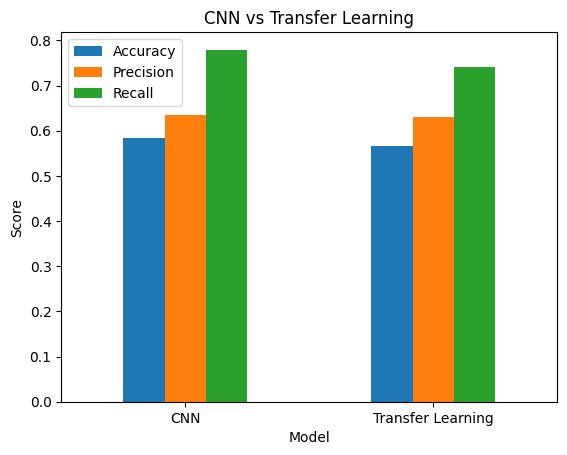

In [26]:
import matplotlib.pyplot as plt

results.set_index("Model").plot(kind="bar")
plt.title("CNN vs Transfer Learning")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

In [27]:
model.save("pneumonia_model.keras")

In [30]:
import os
size_mb = os.path.getsize("pneumonia_model.keras") / (1024*1024)
print(f"{size_mb:.2f} MB")

127.86 MB


In [29]:
import zipfile

with zipfile.ZipFile("pneumonia_model.zip", "w", zipfile.ZIP_DEFLATED) as zipf:
    zipf.write("pneumonia_cnn_model.h5")

print("Compressed successfully")

Compressed successfully


In [31]:
import os

size_mb = os.path.getsize("pneumonia_model.zip") / (1024 * 1024)

print(f"ZIP File Size: {size_mb:.2f} MB")

ZIP File Size: 92.62 MB


In [32]:
from google.colab import files

files.download("pneumonia_model.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>